In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load the dataset
df=pd.read_csv("creditcard.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
# Summary of the dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
labels=["Normal","Fraud"]

Text(0, 0.5, 'No. Of Occurence')

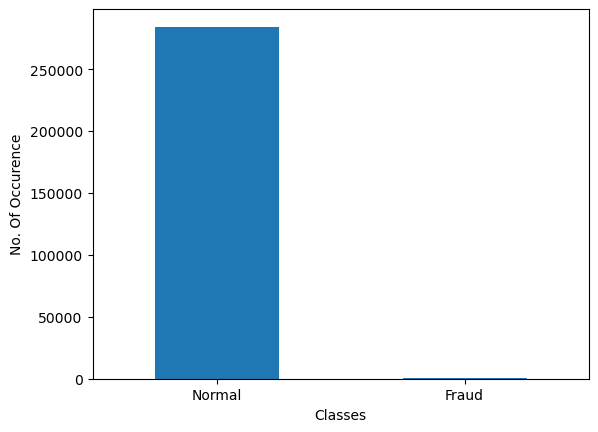

In [9]:
# Distribution of classes
class_set=pd.Series(df['Class']).value_counts()
class_set.plot(kind='bar',rot=0)
plt.tittle=("Class Distribution of Transaction")
plt.xticks(range(2),labels)
plt.xlabel("Classes")
plt.ylabel("No. Of Occurence")

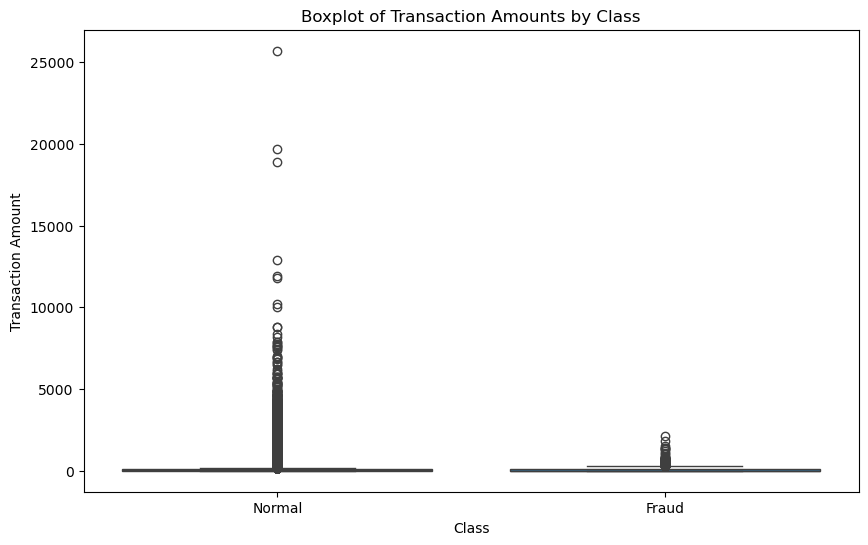

In [10]:
# Boxplot of Transaction Amounts by Class
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Boxplot of Transaction Amounts by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")
plt.xticks(ticks=[0, 1], labels=["Normal", "Fraud"])
plt.show()

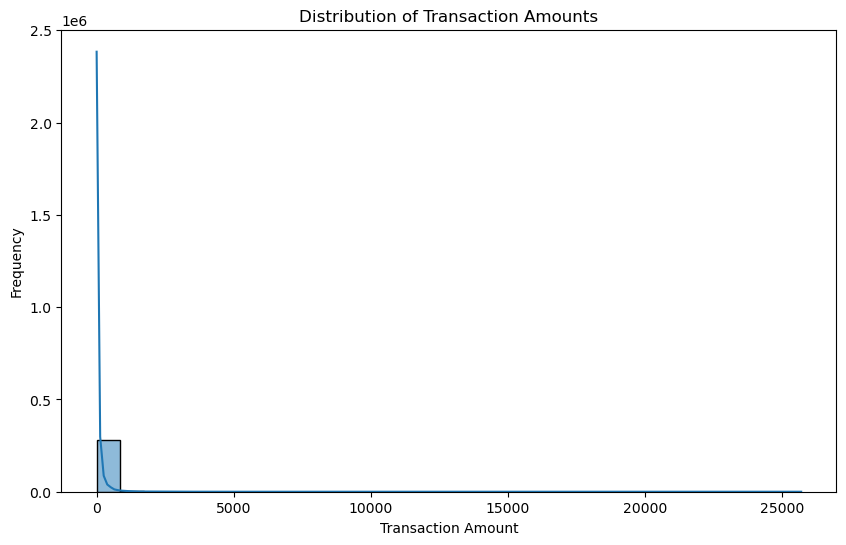

In [11]:
# Distribution of Transaction Amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()


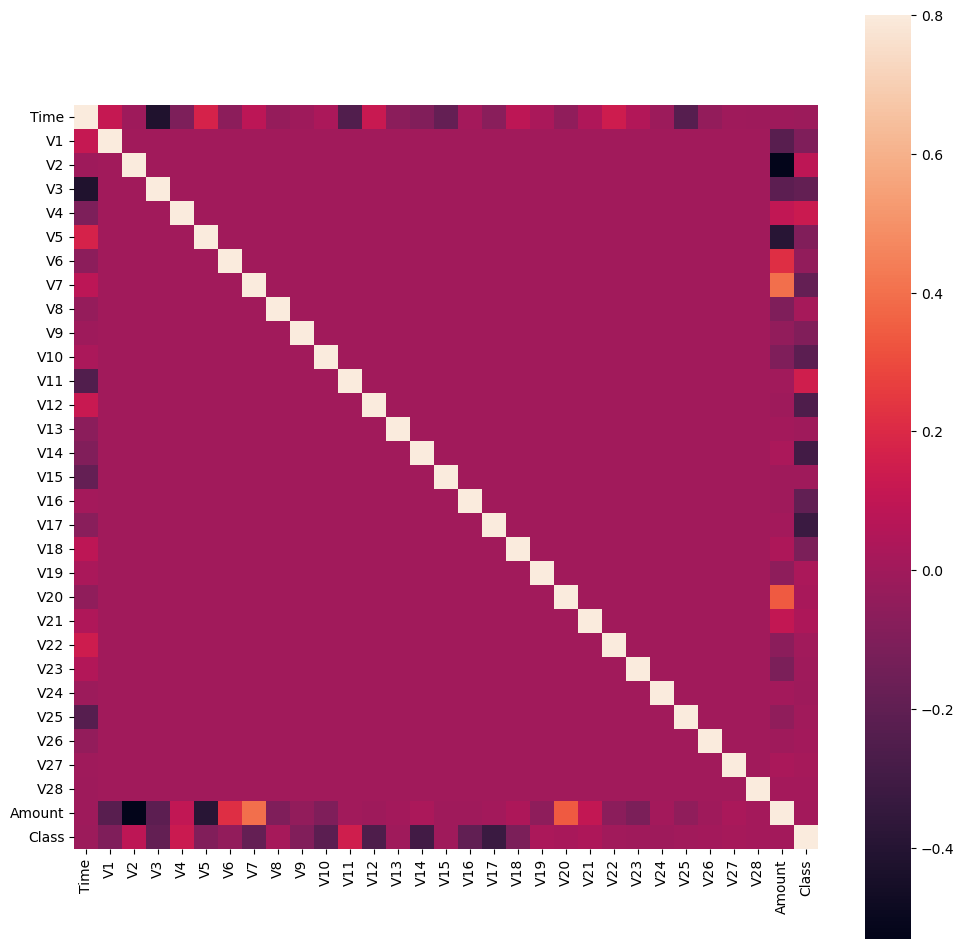

In [12]:
# Correlation heatmap
corr_f=df.corr()
top_cor=corr_f.index
fig = plt.figure(figsize = (12,12))
g=sns.heatmap(df[top_cor].corr(),vmax = .8, square = True)

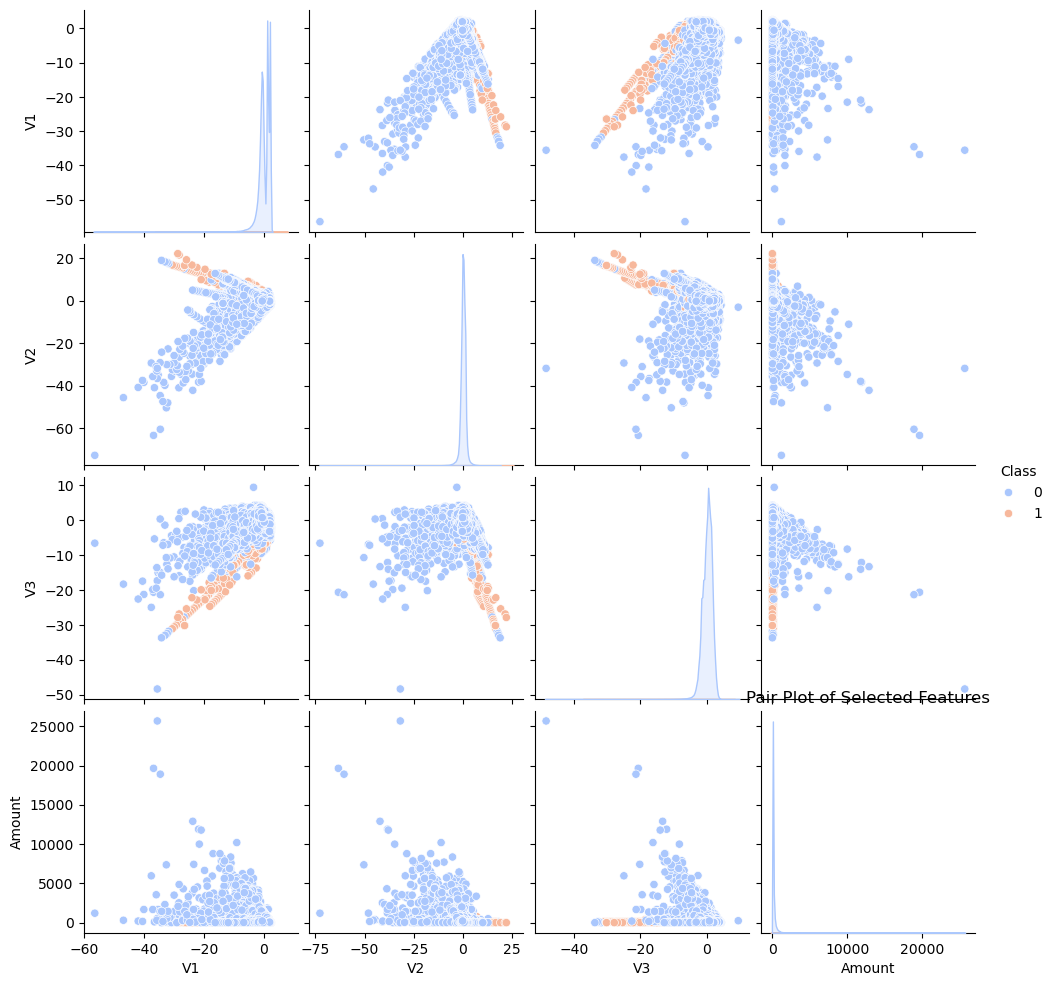

In [13]:
# Pair plot of selected features
selected_features = ['V1', 'V2', 'V3', 'Amount', 'Class']
sns.pairplot(df[selected_features], hue='Class', palette='coolwarm')
plt.title("Pair Plot of Selected Features")
plt.show() 

In [14]:
x = df.iloc[:, 1:30].values
y = df.iloc[:, 30].values

In [15]:
# Split data
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.2, random_state=2)

In [16]:
xtrain

array([[-6.26901618e-01,  1.17279004e+00,  1.75062348e+00, ...,
        -3.75144985e-01, -8.12149281e-02,  1.99900000e+01],
       [-6.06816910e-03, -2.88593204e+00, -7.64537956e-01, ...,
        -1.57440510e-01,  1.30219279e-01,  7.51120000e+02],
       [-5.31513678e-01,  6.11989548e-01,  1.67751021e+00, ...,
        -2.19301917e-02, -2.45349546e-01,  2.06700000e+01],
       ...,
       [-7.99005360e-01,  2.05982104e-01,  1.51217791e+00, ...,
        -2.14302693e-02,  5.02336253e-02,  7.54600000e+01],
       [ 2.01251198e+00, -5.51156625e-02, -1.24533038e+00, ...,
        -9.09007278e-03, -6.14920442e-02,  1.26200000e+01],
       [ 1.29285632e+00, -1.11275744e+00,  1.76139737e+00, ...,
         7.86617917e-02,  2.72844881e-02,  1.00000000e+00]])

### Logistic Regression

In [18]:
model=LogisticRegression()
model.fit(xtrain, ytrain)

LogisticRegression()

In [19]:
# Training_data evalaution
ypred=model.predict(xtrain)
print(f"Accuracy %.2f%% \n"% (accuracy_score(ytrain,ypred)*100))
print("Confusion Matrix :\n",confusion_matrix(ytrain,ypred))
print("\nClassifiaction report : \n",classification_report(ytrain,ypred))


Accuracy 99.92% 

Confusion Matrix :
 [[227393     44]
 [   143    265]]

Classifiaction report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    227437
           1       0.86      0.65      0.74       408

    accuracy                           1.00    227845
   macro avg       0.93      0.82      0.87    227845
weighted avg       1.00      1.00      1.00    227845



In [20]:
# Testing_data evalaution
ypredtest=model.predict(xtest)
print(f"Accuracy %.2f%% \n"% (accuracy_score(ytest,ypredtest)*100))
print("\nClassifiaction report : \n",classification_report(ytest,ypredtest))

Accuracy 99.94% 


Classifiaction report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56878
           1       0.83      0.74      0.78        84

    accuracy                           1.00     56962
   macro avg       0.91      0.87      0.89     56962
weighted avg       1.00      1.00      1.00     56962



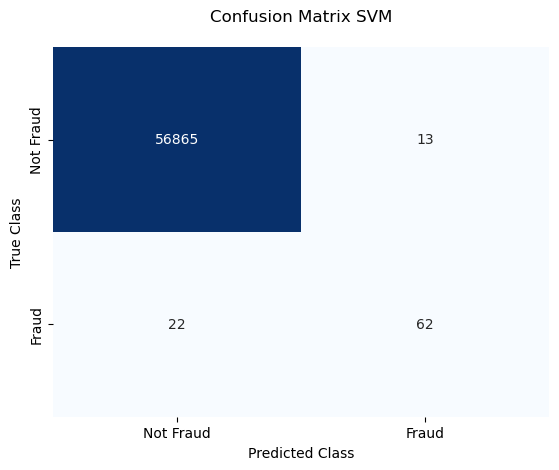

In [21]:
matrix = confusion_matrix(ytest,ypredtest)
df_logi=pd.DataFrame(matrix,index=['Not Fraud','Fraud'],columns=['Not Fraud','Fraud'])

sns.heatmap(df_logi, annot=True,cbar=None, fmt = 'g',cmap="Blues")
plt.title("Confusion Matrix SVM\n")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [22]:
# ROC curve
def plot_roc_curve(ytest, ypred_proba, model_name):
    fpr, tpr, _ = roc_curve(ytest, ypred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

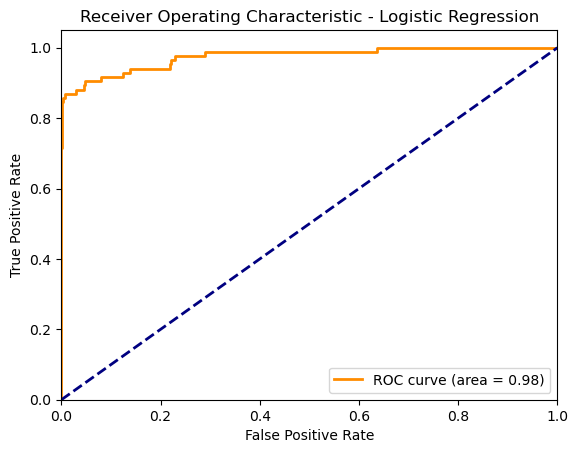

In [23]:
plot_roc_curve(ytest, model.predict_proba(xtest)[:, 1], "Logistic Regression")

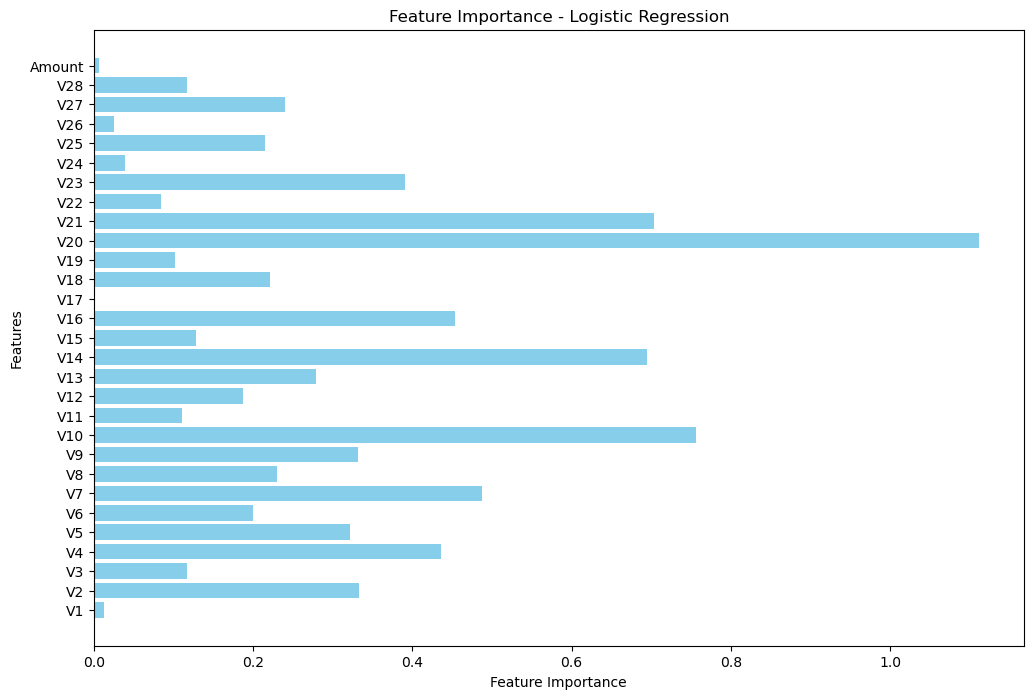

In [24]:
# 5. Feature Importance for Logistic Regression
feature_importance = abs(model.coef_[0])
feature_names = df.columns[1:30]
plt.figure(figsize=(12, 8))
plt.barh(feature_names, feature_importance, color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Logistic Regression")
plt.show()

#

#### Input Data Prediction

In [27]:
# Function to make predictions
def make_prediction(input_d):
    feature = np.asarray(input_d, dtype=np.float64)
    predi = model.predict(feature.reshape(1, -1))
    if predi[0] == 0:
        return "It is normal transaction"
    else:
        return "It is fraud transaction"

In [28]:
#Input Data
input_d=input("Enter all required Feature Values")
input_d=input_d.split(",")

Enter all required Feature Values -1.94652513121534,-0.0449005054418194,-0.405570068378956,-1.01305733702394,2.94196769950545,2.95505339674562,-0.0630631473635638,0.855546309018146,0.0499669002270836,0.573742508037695,-0.0812565147381817,-0.215745003282808,0.0441606277765361,0.0338977566837455,1.19071767502074,0.578843475256385,-0.975667025451307,0.0440628177757039,0.488602868957758,-0.216715254448926,-0.579525934402369,-0.799228952914653,0.870300215304704,0.983421492506598,0.321201132609584,0.149649876930755,0.707518836410842,0.014599751533029,0.89


In [29]:
make_prediction(input_d)

'It is normal transaction'

### Support Vector Machine


In [31]:
model_svc=SVC()
model_svc.fit(xtrain,ytrain)

SVC()

In [32]:
ypred_svm=model_svc.predict(xtest)

In [33]:
print(f"Accuracy %.2f%% "% (accuracy_score(ytest,ypred_svm)*100))
print("Precision SVM: ",precision_score(ytest,ypred_svm))
print("Recall SVM:",recall_score(ytest,ypred_svm))
print("F1 Score SVM:", f1_score(ytest, ypred_svm))

Accuracy 99.89% 
Precision SVM:  0.8
Recall SVM: 0.38095238095238093
F1 Score SVM: 0.5161290322580645


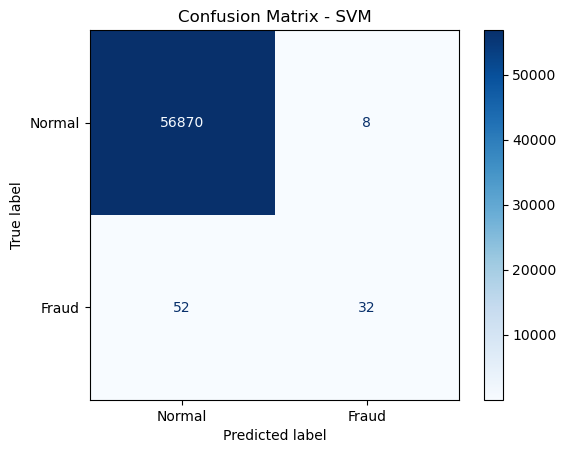

In [63]:
# Confusion matrix for SVM
cnf_matrix_svm = confusion_matrix(ytest, ypred_svm)
ConfusionMatrixDisplay(cnf_matrix_svm, display_labels=labels).plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()